
# Worksheet 4 — Fully Connected Neural Network for Devnagari Digit Classification

This notebook completes the worksheet tasks:
1. Load and preprocess the Devnagari digit dataset using **PIL**.
2. Build a **Sequential** FCN with hidden layers **64, 128, 256** using **sigmoid**.
3. Compile the model.
4. Train the model with **batch size = 128**, **epochs = 20**, and **validation_split = 0.2**.
5. Evaluate on the test set.
6. Save and load the model as **.h5**.
7. Make predictions and visualize results.

> Note: the worksheet asks for one-hot encoding in the data preparation task, so this notebook uses one-hot labels with `categorical_crossentropy` to keep preprocessing and loss consistent.



## 1. Imports


In [3]:

import os
import zipfile
import shutil
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0



## 2. Locate / extract the dataset
This cell looks for:
- an extracted dataset folder containing `Train/` and `Test/`, or
- a zip file such as **Copy of devnagari digit.zip** and extracts it automatically.


In [4]:

possible_zip_names = [
    'Copy of devnagari digit.zip',
    'devnagari digit.zip',
    'devnagari_digit.zip',
    'dataset.zip'
]

possible_roots = [
    '.',
    './DevanagariHandwrittenDigitDataset',
    './dataset',
    '/mnt/data',
    '/mnt/data/DevanagariHandwrittenDigitDataset',
    '/mnt/data/dataset'
]

# Extract zip if needed
zip_found = None
for name in possible_zip_names:
    if os.path.exists(name):
        zip_found = name
        break
    if os.path.exists(os.path.join('/mnt/data', name)):
        zip_found = os.path.join('/mnt/data', name)
        break

if zip_found and not os.path.exists('DevanagariHandwrittenDigitDataset'):
    with zipfile.ZipFile(zip_found, 'r') as zf:
        zf.extractall('.')
    print(f'Extracted: {zip_found}')

# Find dataset root
DATASET_ROOT = None
candidates = [
    '.',
    'DevanagariHandwrittenDigitDataset',
    'dataset',
    '/mnt/data',
    '/mnt/data/DevanagariHandwrittenDigitDataset',
    '/mnt/data/dataset'
]

for root in candidates:
    train_candidate = os.path.join(root, 'Train')
    test_candidate = os.path.join(root, 'Test')
    if os.path.isdir(train_candidate) and os.path.isdir(test_candidate):
        DATASET_ROOT = root
        break

if DATASET_ROOT is None:
    # Search recursively as a fallback
    for root, dirs, files in os.walk('.'):
        if 'Train' in dirs and 'Test' in dirs:
            DATASET_ROOT = root
            break

if DATASET_ROOT is None:
    raise FileNotFoundError('Could not find dataset root containing Train/ and Test/ folders.')

train_dir = os.path.join(DATASET_ROOT, 'Train')
test_dir = os.path.join(DATASET_ROOT, 'Test')

print('Dataset root:', os.path.abspath(DATASET_ROOT))
print('Train dir   :', os.path.abspath(train_dir))
print('Test dir    :', os.path.abspath(test_dir))


Dataset root: c:\Users\Acer\Downloads\Copy of devnagari digit\DevanagariHandwrittenDigitDataset
Train dir   : c:\Users\Acer\Downloads\Copy of devnagari digit\DevanagariHandwrittenDigitDataset\Train
Test dir    : c:\Users\Acer\Downloads\Copy of devnagari digit\DevanagariHandwrittenDigitDataset\Test



## 3. Load and preprocess images with PIL
- convert to grayscale
- resize to **28 × 28**
- normalize to **[0, 1]**
- create labels from folder names


In [5]:

img_height, img_width = 28, 28
num_classes = 10


def load_images_from_folder(folder, img_size=(28, 28)):
    images = []
    labels = []

    class_names = sorted([
        d for d in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, d))
    ])
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert('L')
                img = img.resize(img_size)
                img = np.array(img, dtype=np.float32) / 255.0
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f'Skipping {img_path}: {e}')

    return np.array(images), np.array(labels), class_names, class_map


x_train, y_train_int, class_names, class_map = load_images_from_folder(train_dir, (img_width, img_height))
x_test, y_test_int, _, _ = load_images_from_folder(test_dir, (img_width, img_height))

print('Class names:', class_names)
print('Class map  :', class_map)
print('x_train shape before reshape:', x_train.shape)
print('y_train shape:', y_train_int.shape)
print('x_test shape before reshape :', x_test.shape)
print('y_test shape :', y_test_int.shape)


Class names: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Class map  : {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
x_train shape before reshape: (17000, 28, 28)
y_train shape: (17000,)
x_test shape before reshape : (3000, 28, 28)
y_test shape : (3000,)


In [6]:

# Reshape for Keras: (num_samples, 28, 28, 1)
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train_int, num_classes=num_classes)
y_test = to_categorical(y_test_int, num_classes=num_classes)

print('x_train shape after reshape:', x_train.shape)
print('y_train shape after one-hot:', y_train.shape)
print('x_test shape after reshape :', x_test.shape)
print('y_test shape after one-hot :', y_test.shape)


x_train shape after reshape: (17000, 28, 28, 1)
y_train shape after one-hot: (17000, 10)
x_test shape after reshape : (3000, 28, 28, 1)
y_test shape after one-hot : (3000, 10)



## 4. Visualize sample training images


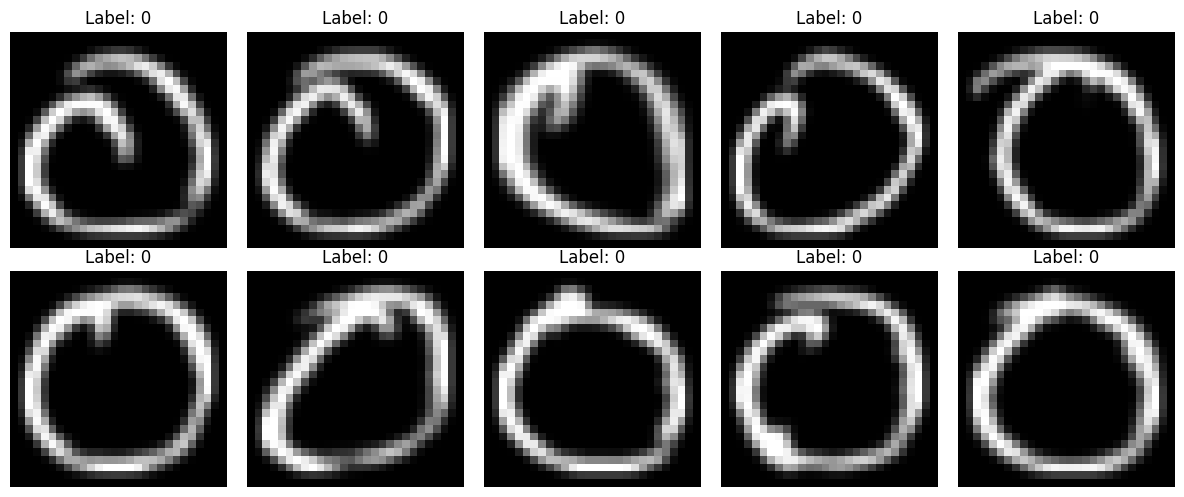

In [7]:

plt.figure(figsize=(12, 5))
for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f'Label: {np.argmax(y_train[i])}')
    plt.axis('off')
plt.tight_layout()
plt.show()



## 5. Build the Fully Connected Network (FCN)
Architecture required by the worksheet:
- Flatten
- Dense(64, sigmoid)
- Dense(128, sigmoid)
- Dense(256, sigmoid)
- Dense(10, softmax)


In [8]:

model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)


## 6. Compile the model
Using:
- optimizer: **adam**
- loss: **categorical_crossentropy**
- metric: **accuracy**


In [9]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



## 7. Train the model
Worksheet settings:
- **batch_size = 128**
- **epochs = 20**
- **validation_split = 0.2**

Callbacks are added for:
- saving the best model
- early stopping if validation loss stops improving


In [10]:

batch_size = 128
epochs = 20

callbacks = [
    ModelCheckpoint(
        filepath='best_devnagari_fcn.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2828 - loss: 1.9453    
Epoch 1: val_loss improved from None to 7.38088, saving model to best_devnagari_fcn.keras

Epoch 1: finished saving model to best_devnagari_fcn.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4775 - loss: 1.5809 - val_accuracy: 0.0000e+00 - val_loss: 7.3809
Epoch 2/20
 84/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7946 - loss: 0.6317
Epoch 2: val_loss did not improve from 7.38088
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8330 - loss: 0.4974 - val_accuracy: 0.0000e+00 - val_loss: 8.6542
Epoch 3/20
 88/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9035 - loss: 0.3080
Epoch 3: val_loss did not improve from 7.38088
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9140 - loss: 0.2844 - val_accuracy: 0.0000e+00 - val_loss: 9.2680
Epoch 4/20
 85/107 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9384 - loss: 0.2197
Epoch 4: val_loss did not improve from 7.3808


## 8. Plot training and validation curves
These graphs are part of the worksheet deliverables.


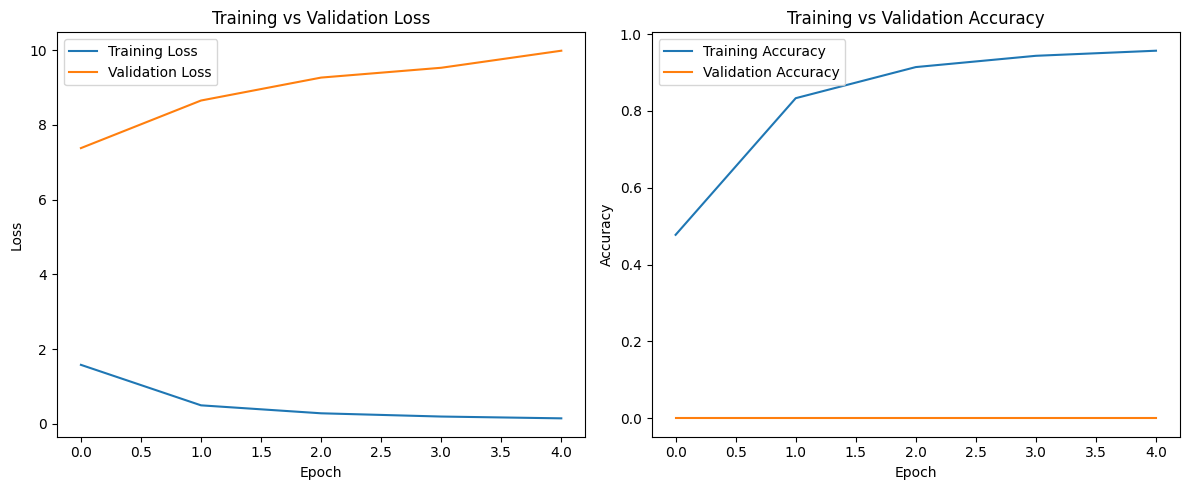

In [11]:

train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()



## 9. Evaluate on the test set


In [12]:

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')


94/94 - 0s - 975us/step - accuracy: 0.6097 - loss: 2.0955
Test Loss: 2.0955
Test Accuracy: 0.6097



## 10. Make predictions
Convert softmax probabilities into digit labels using `np.argmax()`.


In [13]:

predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print('First 10 predicted labels:', predicted_labels[:10])
print('First 10 true labels     :', true_labels[:10])


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step
First 10 predicted labels: [0 0 0 0 0 0 0 0 0 0]
First 10 true labels     : [0 0 0 0 0 0 0 0 0 0]


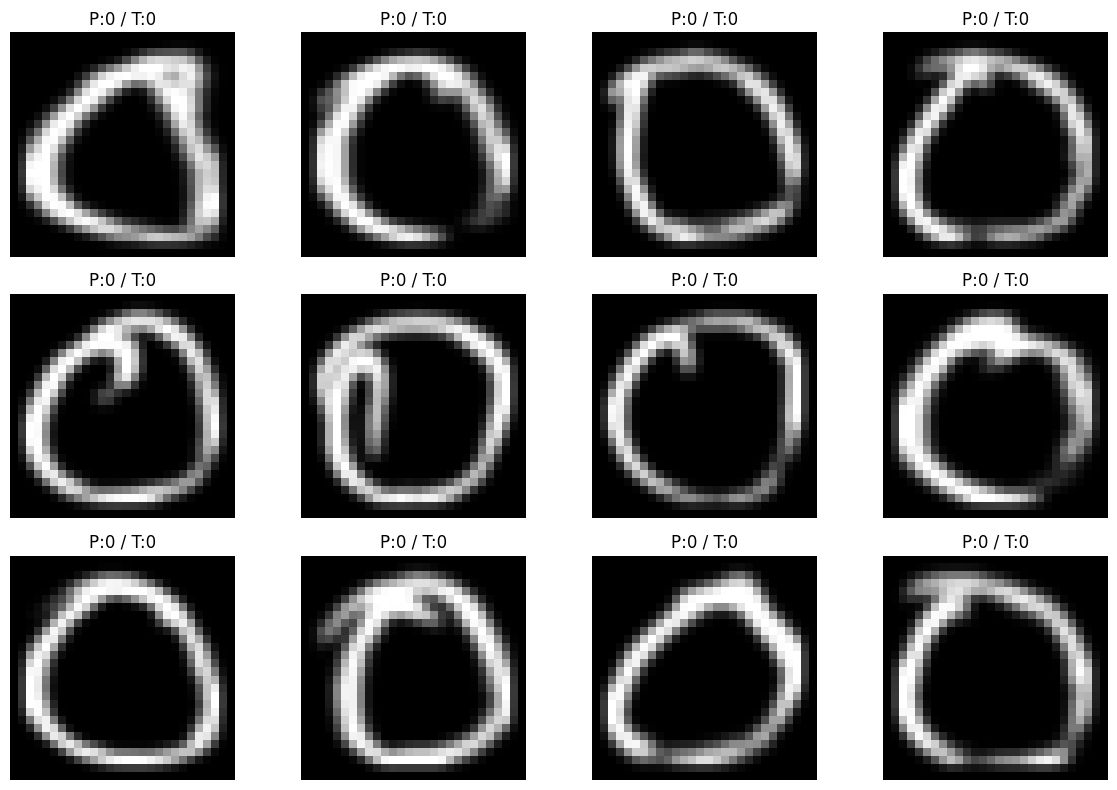

In [14]:

plt.figure(figsize=(12, 8))
for i in range(min(12, len(x_test))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f'P:{predicted_labels[i]} / T:{true_labels[i]}')
    plt.axis('off')
plt.tight_layout()
plt.show()



## 11. Classification report and confusion matrix (extra analysis)
This is optional, but useful for interpreting model performance.


In [15]:

print(classification_report(true_labels, predicted_labels, digits=4))


              precision    recall  f1-score   support

           0     0.5158    0.9767    0.6751       300
           1     0.7033    0.9800    0.8189       300
           2     0.0000    0.0000    0.0000       300
           3     0.3898    0.8900    0.5421       300
           4     0.7062    0.9533    0.8113       300
           5     0.7943    0.7467    0.7698       300
           6     0.7624    0.7700    0.7662       300
           7     0.6903    0.7800    0.7324       300
           8     0.0000    0.0000    0.0000       300
           9     0.0000    0.0000    0.0000       300

    accuracy                         0.6097      3000
   macro avg     0.4562    0.6097    0.5116      3000
weighted avg     0.4562    0.6097    0.5116      3000



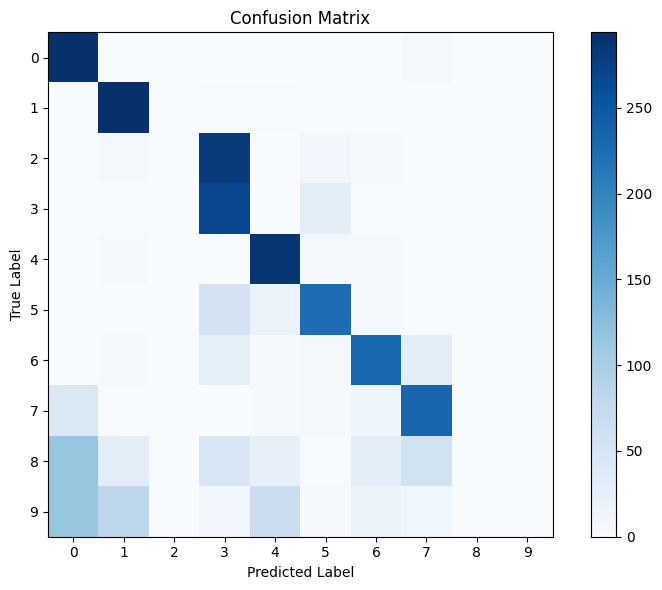

In [16]:

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.colorbar()
plt.xticks(range(num_classes))
plt.yticks(range(num_classes))
plt.tight_layout()
plt.show()



## 12. Save the trained model as `.h5`


In [17]:

model.save('devnagari_fcn.h5')
print('Saved model as devnagari_fcn.h5')


Saved model as devnagari_fcn.h5



## 13. Load the saved model and re-evaluate


In [18]:

loaded_model = tf.keras.models.load_model('devnagari_fcn.h5')
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f'Reloaded Model Loss: {loaded_loss:.4f}')
print(f'Reloaded Model Accuracy: {loaded_acc:.4f}')


94/94 - 0s - 2ms/step - accuracy: 0.6097 - loss: 2.0955
Reloaded Model Loss: 2.0955
Reloaded Model Accuracy: 0.6097
